# Hybrid Recommender Model

Combining SVD (collaborative filtering) + TF-IDF (content-based) into a weighted hybrid.

`final_score = alpha × CF_score + (1 - alpha) × content_score`

In [5]:
import sys
import os
import joblib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sys.path.append('..')
from src.utils.data_loader import load_movielens
from src.hybrid.hybrid_recommender import HybridRecommender

## 1. Load Data and Saved Models

In [6]:
ratings_df, movies_df = load_movielens(
    ratings_path='../data/raw/u.data',
    movies_path='../data/raw/u.item'
)

# Load models saved by Member 1 and this notebook (03)
svd_model     = joblib.load('../models/svd_model.pkl')
content_model = joblib.load('../models/content_model.pkl')

print('Models loaded successfully!')
print('Ratings:', ratings_df.shape)
print('Movies:', movies_df.shape)

Models loaded successfully!
Ratings: (100000, 4)
Movies: (1682, 22)


## 2. Basic Hybrid Recommendation (alpha=0.7)

In [7]:
hybrid = HybridRecommender(cf_model=svd_model, content_model=content_model, alpha=0.7)
recs = hybrid.recommend(user_id=1, movies_df=movies_df, n=10)

print('Top 10 recommendations for User 1 (alpha=0.7):')
display(recs)

Top 10 recommendations for User 1 (alpha=0.7):


,item_id,title,hybrid_score
0,923,Raise the Red Lantern (1991),0.908849
1,64,"Shawshank Redemption, The (1994)",0.897172
2,178,12 Angry Men (1957),0.877279
3,150,Swingers (1996),0.875037
4,45,Eat Drink Man Woman (1994),0.871872
5,523,Cool Hand Luke (1967),0.862820
6,165,Jean de Florette (1986),0.862387
7,223,Sling Blade (1996),0.860196
8,285,Secrets & Lies (1996),0.858901
9,134,Citizen Kane (1941),0.853028


## 3. Alpha Experiments — Which Value Works Best?

Alpha controls the balance:
- `alpha=1.0` → 100% collaborative filtering (SVD)
- `alpha=0.0` → 100% content-based (TF-IDF)
- `alpha=0.7` → 70% CF + 30% content (default)

In [8]:
alphas = [0.3, 0.5, 0.7, 0.9]
user_id = 1

for alpha in alphas:
    hybrid.alpha = alpha
    recs = hybrid.recommend(user_id=user_id, movies_df=movies_df, n=5)
    print(f'\n--- alpha={alpha} (CF weight={alpha}, Content weight={round(1-alpha,1)}) ---')
    print(recs[['title', 'hybrid_score']].to_string(index=False))


--- alpha=0.3 (CF weight=0.3, Content weight=0.7) ---
                          title  hybrid_score
                Swingers (1996)      0.946444
     Eat Drink Man Woman (1994)      0.945088
          Cool Hand Luke (1967)      0.941209
Welcome to the Dollhouse (1995)      0.925944
                 Ed Wood (1994)      0.920473

--- alpha=0.5 (CF weight=0.5, Content weight=0.5) ---
                           title  hybrid_score
                 Swingers (1996)      0.910740
      Eat Drink Man Woman (1994)      0.908480
           Cool Hand Luke (1967)      0.902015
    Raise the Red Lantern (1991)      0.893419
Shawshank Redemption, The (1994)      0.885078

--- alpha=0.7 (CF weight=0.7, Content weight=0.3) ---
                           title  hybrid_score
    Raise the Red Lantern (1991)      0.908849
Shawshank Redemption, The (1994)      0.897172
             12 Angry Men (1957)      0.877279
                 Swingers (1996)      0.875037
      Eat Drink Man Woman (1994)      0.87

## 4. Visualize Score Distribution Across Alpha Values

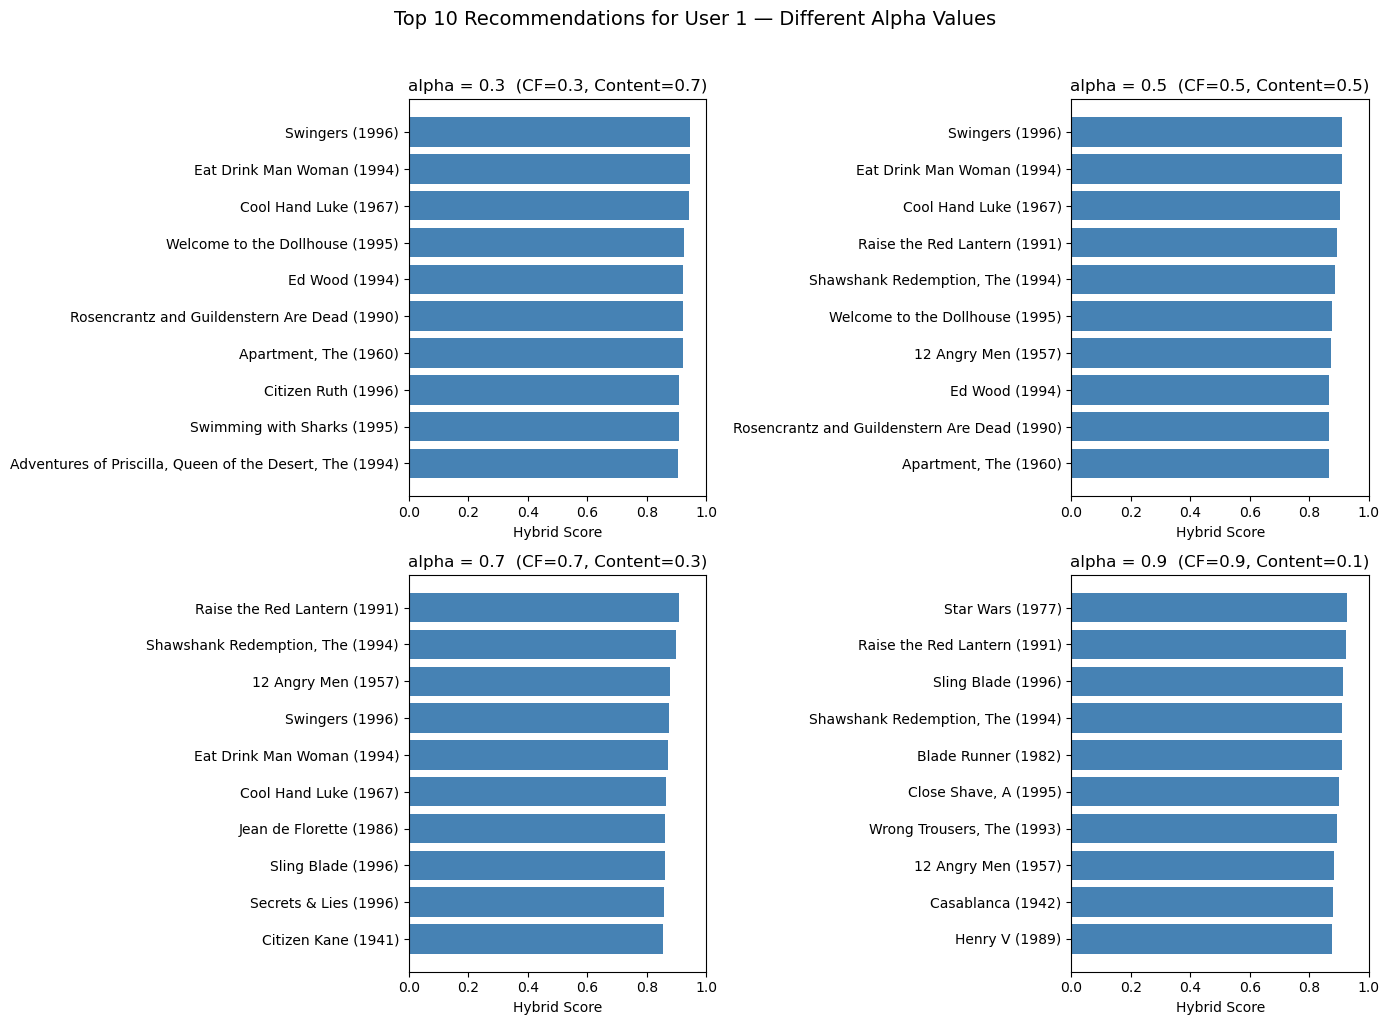

Saved: reports/figures/hybrid_alpha_comparison.png


In [9]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, alpha in enumerate(alphas):
    hybrid.alpha = alpha
    recs = hybrid.recommend(user_id=1, movies_df=movies_df, n=10)
    axes[i].barh(recs['title'], recs['hybrid_score'], color='steelblue')
    axes[i].set_title(f'alpha = {alpha}  (CF={alpha}, Content={round(1-alpha,1)})')
    axes[i].set_xlabel('Hybrid Score')
    axes[i].invert_yaxis()
    axes[i].set_xlim(0, 1)

plt.suptitle('Top 10 Recommendations for User 1 — Different Alpha Values', fontsize=14, y=1.02)
plt.tight_layout()
os.makedirs('../reports/figures', exist_ok=True)
plt.savefig('../reports/figures/hybrid_alpha_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: reports/figures/hybrid_alpha_comparison.png')

## 5. User Feedback Loop Simulation

Simulate a user rating 3 new movies highly, then re-run recommendations to show they change.

In [10]:
# Reset alpha to default
hybrid.alpha = 0.7
user_id = 5  # pick a test user

# --- BEFORE feedback ---
recs_before = hybrid.recommend(user_id=user_id, movies_df=movies_df, n=10)
print('=== BEFORE Feedback — Top 10 for User', user_id, '===')
display(recs_before[['title', 'hybrid_score']])

=== BEFORE Feedback — Top 10 for User 5 ===


,title,hybrid_score
0,Cool Hand Luke (1967),0.888521
1,Citizen Kane (1941),0.846501
2,8 1/2 (1963),0.823867
3,Eat Drink Man Woman (1994),0.818979
4,Rosencrantz and Guildenstern Are Dead (1990),0.814940
5,As Good As It Gets (1997),0.803557
6,Fargo (1996),0.800597
7,12 Angry Men (1957),0.800338
8,"Empire Strikes Back, The (1980)",0.792618
9,Three Colors: Red (1994),0.791107


In [11]:
# Simulate: user rates 3 new Horror movies with rating=5
new_ratings = pd.DataFrame([
    {'user_id': user_id, 'item_id': 294, 'rating': 5, 'timestamp': 888888888},  # Scream
    {'user_id': user_id, 'item_id': 127, 'rating': 5, 'timestamp': 888888889},  # Frighteners
    {'user_id': user_id, 'item_id': 118, 'rating': 5, 'timestamp': 888888890},  # Twister
])

ratings_updated = pd.concat([ratings_df, new_ratings], ignore_index=True)
print(f'Original ratings: {len(ratings_df)}')
print(f'Updated ratings:  {len(ratings_updated)}')
print('\nNew ratings added:')
display(new_ratings.merge(movies_df[['item_id','title']], on='item_id'))

Original ratings: 100000
Updated ratings:  100003

New ratings added:


,user_id,item_id,rating,timestamp,title
0,5,294,5,888888888,Liar Liar (1997)
1,5,127,5,888888889,"Godfather, The (1972)"
2,5,118,5,888888890,Twister (1996)


In [12]:
from surprise import SVD
from src.utils.data_loader import to_surprise_dataset
from src.collaborative.matrix_factorization import train_svd

# Retrain SVD on updated ratings
updated_data    = to_surprise_dataset(ratings_updated)
svd_updated, _  = train_svd(updated_data)

hybrid_updated  = HybridRecommender(
    cf_model=svd_updated,
    content_model=content_model,
    alpha=0.7
)

recs_after = hybrid_updated.recommend(user_id=user_id, movies_df=movies_df, n=10)
print('=== AFTER Feedback — Top 10 for User', user_id, '===')
display(recs_after[['title', 'hybrid_score']])

=== AFTER Feedback — Top 10 for User 5 ===


,title,hybrid_score
0,Monty Python and the Holy Grail (1974),0.858495
1,Secrets & Lies (1996),0.851138
2,Cool Hand Luke (1967),0.837992
3,One Flew Over the Cuckoo's Nest (1975),0.813281
4,Eat Drink Man Woman (1994),0.811798
5,"Shawshank Redemption, The (1994)",0.811757
6,Return of the Jedi (1983),0.808678
7,As Good As It Gets (1997),0.802452
8,Night on Earth (1991),0.792484
9,Rosencrantz and Guildenstern Are Dead (1990),0.788104


In [13]:
# Side-by-side comparison
before_titles = set(recs_before['title'].tolist())
after_titles  = set(recs_after['title'].tolist())

new_in_recs     = after_titles  - before_titles
removed_in_recs = before_titles - after_titles

print('New movies that appeared AFTER feedback:')
for t in new_in_recs:
    print(' +', t)

print('\nMovies that DROPPED OUT after feedback:')
for t in removed_in_recs:
    print(' -', t)

print('\n✅ Recommendations changed based on user feedback — feedback loop works!')

New movies that appeared AFTER feedback:
 + Secrets & Lies (1996)
 + One Flew Over the Cuckoo's Nest (1975)
 + Monty Python and the Holy Grail (1974)
 + Return of the Jedi (1983)
 + Shawshank Redemption, The (1994)
 + Night on Earth (1991)

Movies that DROPPED OUT after feedback:
 - Fargo (1996)
 - Empire Strikes Back, The (1980)
 - Citizen Kane (1941)
 - 8 1/2 (1963)
 - Three Colors: Red (1994)
 - 12 Angry Men (1957)

✅ Recommendations changed based on user feedback — feedback loop works!
